# Random Forest

## Learning objective

This notebook covers the **random forest**, an *ensemble* of decision trees that
is far more stable than any single tree. You should finish able to:

- explain **bagging** (bootstrap aggregating) and why averaging reduces variance,
- explain **bootstrap samples**, **random feature subsets**, and **majority
  voting**,
- implement a `RandomForestClassifierScratch` from scratch on top of a simple
  decision tree, and
- compare a single tree with a forest and discuss decorrelation, out-of-bag
  intuition, and limitations.

## The mathematical idea

A single decision tree has **low bias but high variance**: it can fit complex
boundaries, but small changes in the training data lead to very different trees.
A random forest reduces that variance by averaging many trees, each trained on a
slightly different view of the data.

**Bagging (bootstrap aggregating).** From a training set of $n$ points we draw a
**bootstrap sample**: $n$ points sampled *with replacement*. Each bootstrap
sample omits some original points and duplicates others, so every tree sees a
different dataset. If the trees were independent and each had variance
$\sigma^2$, the variance of the average of $T$ of them would be $\sigma^2 / T$.

**Random feature subsets.** Trees trained on bootstrap samples alone are still
correlated, because a few strong features dominate the top splits of every tree.
Random forests add a second source of randomness: at each split a tree may only
consider a **random subset of the features** (often about $\sqrt{d}$ of the $d$
features). This **decorrelates** the trees, and averaging decorrelated trees
reduces variance much more than averaging correlated ones.

**Majority voting.** For classification, each tree votes for a class and the
forest predicts the **most common vote** across the trees.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

## A reproducible dataset

We use a small two-dimensional, two-class dataset with a curved gap between the
classes (two interleaving “moons”). A boundary like this is hard for the
axis-aligned splits of a single shallow tree, so it is a good setting to see
whether the forest helps.

In [2]:
n_per_class = 120

# Two interleaving half-circles (moons) with a little noise.
t = np.linspace(0, np.pi, n_per_class)
outer = np.column_stack([np.cos(t), np.sin(t)])
inner = np.column_stack([1 - np.cos(t), 1 - np.sin(t) - 0.5])

X = np.vstack([outer, inner]) + rng.normal(scale=0.12, size=(2 * n_per_class, 2))
y = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)]).astype(int)

print('Feature matrix shape:', X.shape)
print('Label distribution:', {0: int((y == 0).sum()), 1: int((y == 1).sum())})

Feature matrix shape: (240, 2)
Label distribution: {0: 120, 1: 120}


## Train/test split

We shuffle with a fixed seed and hold out 30% of the data for testing.

In [3]:
n_samples = X.shape[0]
n_test = int(0.3 * n_samples)

perm = rng.permutation(n_samples)
test_idx, train_idx = perm[:n_test], perm[n_test:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print('Train size:', X_train.shape[0])
print('Test size :', X_test.shape[0])

Train size: 168
Test size : 72


## A simple decision tree

The forest reuses a small CART-style tree, the same kind built in the Decision
Tree notebook, with one addition for the ensemble: at each split it considers
only a **random subset of the features** (`max_features`). It uses Gini impurity
and information gain to pick the best split among the allowed features. Drawing a
fresh feature subset at every node is what decorrelates the trees in the forest.

In [4]:
class SimpleDecisionTree:
    """A CART-style tree that splits on a random subset of features per node."""

    def __init__(self, max_depth=None, min_samples_split=2,
                 max_features=None, random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.rng = np.random.default_rng(random_state)

    @staticmethod
    def _gini(y):
        counts = np.bincount(y)
        proportions = counts / counts.sum()
        return 1.0 - np.sum(proportions ** 2)

    def _feature_subset(self, n_features):
        if self.max_features is None or self.max_features >= n_features:
            return np.arange(n_features)
        return self.rng.choice(n_features, size=self.max_features, replace=False)

    def _best_split(self, X, y):
        n_samples = X.shape[0]
        parent_gini = self._gini(y)
        best_gain = 0.0
        best = None
        for feature in self._feature_subset(X.shape[1]):
            values = np.unique(X[:, feature])
            thresholds = (values[:-1] + values[1:]) / 2.0
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                n_left, n_right = left_mask.sum(), right_mask.sum()
                if n_left == 0 or n_right == 0:
                    continue
                gain = (parent_gini
                        - (n_left / n_samples) * self._gini(y[left_mask])
                        - (n_right / n_samples) * self._gini(y[right_mask]))
                if gain > best_gain:
                    best_gain = gain
                    best = (feature, threshold, left_mask, right_mask)
        return best_gain, best

    def _build(self, X, y, depth):
        depth_reached = self.max_depth is not None and depth >= self.max_depth
        if (len(np.unique(y)) == 1
                or len(y) < self.min_samples_split
                or depth_reached):
            return {'leaf': np.bincount(y).argmax()}

        gain, best = self._best_split(X, y)
        if best is None or gain == 0.0:
            return {'leaf': np.bincount(y).argmax()}

        feature, threshold, left_mask, right_mask = best
        left = self._build(X[left_mask], y[left_mask], depth + 1)
        right = self._build(X[right_mask], y[right_mask], depth + 1)
        return {'feature': feature, 'threshold': threshold,
                'left': left, 'right': right}

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        self.tree_ = self._build(X, y, depth=0)
        return self

    def _predict_one(self, x, node):
        while 'leaf' not in node:
            if x[node['feature']] <= node['threshold']:
                node = node['left']
            else:
                node = node['right']
        return node['leaf']

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(x, self.tree_) for x in X])

## Random forest from scratch

The forest ties everything together:

- **`_bootstrap`** draws $n$ row indices with replacement to build one tree's
  training set.
- **`fit`** grows `n_estimators` trees, each on its own bootstrap sample and each
  restricting splits to a random feature subset of size `max_features`. A single
  seeded generator drives all the randomness so the whole forest is reproducible.
- **`predict`** collects every tree's prediction and returns the **majority
  vote** for each point.

By default `max_features` is set to roughly $\sqrt{d}$, the common rule of thumb
for classification forests.

In [5]:
class RandomForestClassifierScratch:
    """A from-scratch random forest: bagging + random feature subsets + voting."""

    def __init__(self, n_estimators=25, max_depth=None,
                 min_samples_split=2, max_features=None, random_state=0):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state

    def _bootstrap(self, n_samples, rng):
        return rng.integers(0, n_samples, size=n_samples)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        n_samples, n_features = X.shape
        rng = np.random.default_rng(self.random_state)

        # Default rule of thumb: sqrt(d) features considered per split.
        if self.max_features is None:
            self.max_features_ = max(1, int(np.sqrt(n_features)))
        else:
            self.max_features_ = self.max_features

        self.trees_ = []
        for _ in range(self.n_estimators):
            idx = self._bootstrap(n_samples, rng)
            # Derive each tree's seed from the forest generator for reproducibility.
            tree_seed = int(rng.integers(0, 2 ** 32))
            tree = SimpleDecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features_,
                random_state=tree_seed,
            ).fit(X[idx], y[idx])
            self.trees_.append(tree)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        # Stack tree predictions: shape (n_estimators, n_samples).
        all_preds = np.array([tree.predict(X) for tree in self.trees_])
        # Majority vote down the columns.
        return np.array([np.bincount(col).argmax() for col in all_preds.T])

## Single tree versus forest

We train one decision tree and one forest with the same depth limit and compare
train and test accuracy. The single tree often fits the training data a little
better, while the forest typically generalizes better — the signature of
variance reduction through averaging.

In [6]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


single_tree = SimpleDecisionTree(max_depth=4, random_state=0).fit(X_train, y_train)
forest = RandomForestClassifierScratch(
    n_estimators=50, max_depth=4, random_state=0).fit(X_train, y_train)

results = {
    'single tree': {
        'train': accuracy(y_train, single_tree.predict(X_train)),
        'test': accuracy(y_test, single_tree.predict(X_test)),
    },
    'random forest': {
        'train': accuracy(y_train, forest.predict(X_train)),
        'test': accuracy(y_test, forest.predict(X_test)),
    },
}
for name, scores in results.items():
    print(f"{name:>14}: train = {round(scores['train'], 4)}, "
          f"test = {round(scores['test'], 4)}")

   single tree: train = 0.9226, test = 0.8611
 random forest: train = 0.9821, test = 0.9306


## Test accuracy versus number of trees

Adding trees should improve and then stabilize test accuracy: once enough trees
are averaged, the variance is largely removed and more trees give diminishing
returns rather than overfitting.

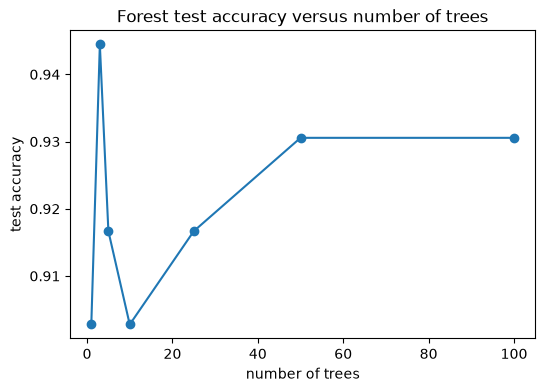

In [7]:
n_tree_grid = [1, 3, 5, 10, 25, 50, 100]
forest_test = []
for n in n_tree_grid:
    f = RandomForestClassifierScratch(
        n_estimators=n, max_depth=4, random_state=0).fit(X_train, y_train)
    forest_test.append(accuracy(y_test, f.predict(X_test)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(n_tree_grid, forest_test, marker='o')
ax.set_xlabel('number of trees')
ax.set_ylabel('test accuracy')
ax.set_title('Forest test accuracy versus number of trees')
plt.show()

## Decision regions for the forest

We shade the forest's predicted class across a dense grid and overlay the
training points. Because the forest averages many axis-aligned trees, its
boundary is smoother and more flexible than the staircase a single shallow tree
would draw on this curved problem.

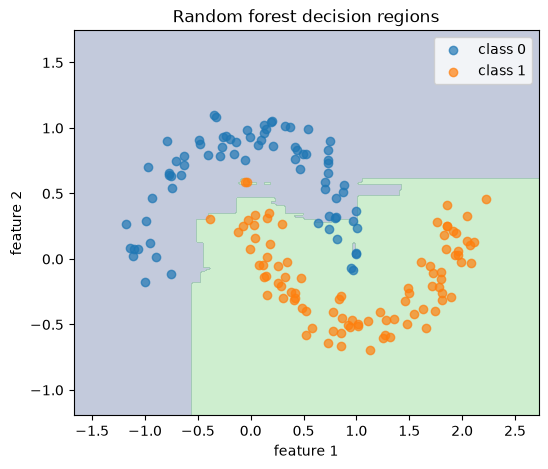

In [8]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid = np.column_stack([xx.ravel(), yy.ravel()])
zz = forest.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx, yy, zz, alpha=0.3, levels=1)
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
           label='class 0', alpha=0.7)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           label='class 1', alpha=0.7)
ax.set_xlabel('feature 1')
ax.set_ylabel('feature 2')
ax.set_title('Random forest decision regions')
ax.legend()
plt.show()

## Interpretation

Comparing the single tree and the forest shows the core benefit of ensembling:
the forest trades a little training-set fit for better, more stable test-set
performance. The accuracy-versus-trees plot shows that benefit arriving and then
leveling off, and the decision-region plot shows a smoother boundary than a lone
shallow tree produces.

### Variance reduction, decorrelation, out-of-bag, and feature randomness

- **Variance reduction.** Each tree is high-variance, but averaging many of them
  cancels much of the noise, so the forest's predictions are far more stable than
  any single tree's.
- **Decorrelation between trees.** Averaging only helps a lot when the trees make
  *different* errors. Bootstrap sampling and per-split random feature subsets
  push the trees to disagree, so their mistakes cancel instead of reinforcing.
- **Out-of-bag intuition.** Each bootstrap sample leaves out roughly a third of
  the training points. Those “out-of-bag” points were unseen by that tree, so
  predicting them with only the trees that excluded them gives a built-in,
  validation-like estimate of accuracy without a separate hold-out set.
- **Feature randomness.** Considering only a subset of features per split is what
  separates a random forest from plain bagged trees; it prevents a few dominant
  features from making every tree look alike.

## Limitations and next steps

- A forest is **less interpretable** than a single tree: there is no longer one
  readable rule set, though feature-importance scores can help.
- It is **more expensive** — many trees to train, store, and query.
- The base trees are still **axis-aligned**, so the forest approximates smooth or
  diagonal boundaries with many small steps rather than fitting them exactly.

Natural next steps are to add **out-of-bag scoring** and **feature-importance**
estimates, to tune `n_estimators`, `max_depth`, and `max_features` with cross-
validation, and to compare against **boosted** trees, which build trees
sequentially to correct earlier errors rather than averaging independent ones.